# 02 - Exploratory Data Analysis


---

Understand the structure, distributions, and patterns in the parsed transaction data.
This analysis will directly inform the fraud label simulation rules in the next notebook.

**Input:** `data/processed/parsed_logs.csv`


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

DATA_PATH = Path('../data/processed/parsed_logs.csv')
print('Setup complete.')

Setup complete.


## 2. Load Data

Load the cleaned CSV produced by `01_parsing.ipynb`.
Parse `timestamp` directly as datetime so time-based operations work immediately.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

print('Shape  :', df.shape)
print('Columns:', list(df.columns))
print()
df.head()

Shape  : (7774, 8)
Columns: ['timestamp', 'user_id', 'txn_type', 'amount', 'currency', 'location', 'device', 'log_format']



,timestamp,user_id,txn_type,amount,currency,location,device,log_format
0,2025-07-05 19:18:10,user1069,withdrawal,2995.12,NaN,London,iPhone 13,pipe_colon
1,2025-07-15 12:56:05,user1076,cashout,4821.85,€,Glasgow,Pixel 6,usr_pipe
2,2025-07-20 05:38:14,user1034,top-up,2191.06,€,NaN,iPhone 13,arrow_bracket
3,2025-06-13 10:04:51,user1068,deposit,1691.09,€,Glasgow,NaN,arrow_bracket
4,2025-07-29 23:47:37,user1014,deposit,3539.50,£,Glasgow,iPhone 13,pipe_bar


## 3. Data Types and Basic Info


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7774 entries, 0 to 7773
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   7774 non-null   datetime64[ns]
 1   user_id     7774 non-null   object        
 2   txn_type    7774 non-null   object        
 3   amount      7774 non-null   float64       
 4   currency    5533 non-null   object        
 5   location    6806 non-null   object        
 6   device      6693 non-null   object        
 7   log_format  7774 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 486.0+ KB


## 4. Missing Values

`currency`, `location`, and `device` have nulls.
Here i quantify exactly how many and what percentage — this decides how i handle them
in feature engineering (fill, flag, or drop).

          null_count  null_%
currency        2241   28.80
location         968   12.50
device          1081   13.90


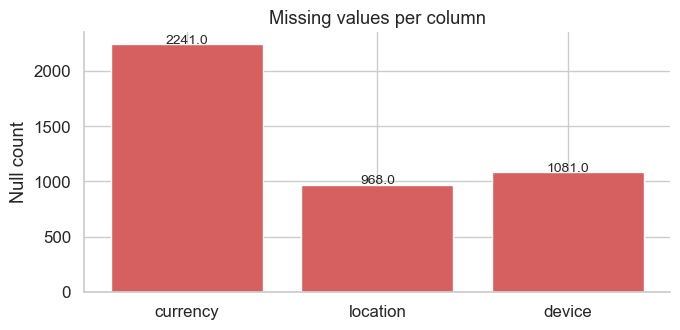

In [4]:
# Count nulls and express as percentage of total rows
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
missing = pd.DataFrame({'null_count': nulls, 'null_%': nulls_pct})
missing = missing[missing['null_count'] > 0]

print(missing.to_string())

# Bar chart of null counts
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(missing.index, missing['null_count'], color=COLORS[3], edgecolor='white')
for i, (col, row) in enumerate(missing.iterrows()):
    ax.text(i, row['null_count'] + 10, str(row['null_count']), ha='center', fontsize=10)
ax.set_ylabel('Null count')
ax.set_title('Missing values per column')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Descriptive Statistics

`describe()` gives count, mean, std, min, quartiles, and max for numeric columns.
For fraud detection the key column is `amount` 

In [5]:
df.describe()

,amount
count,7774.00
mean,2479.18
std,1441.02
min,1.62
25%,1231.76
50%,2464.39
75%,3741.26
max,4998.25


## 6. Transaction Type Distribution


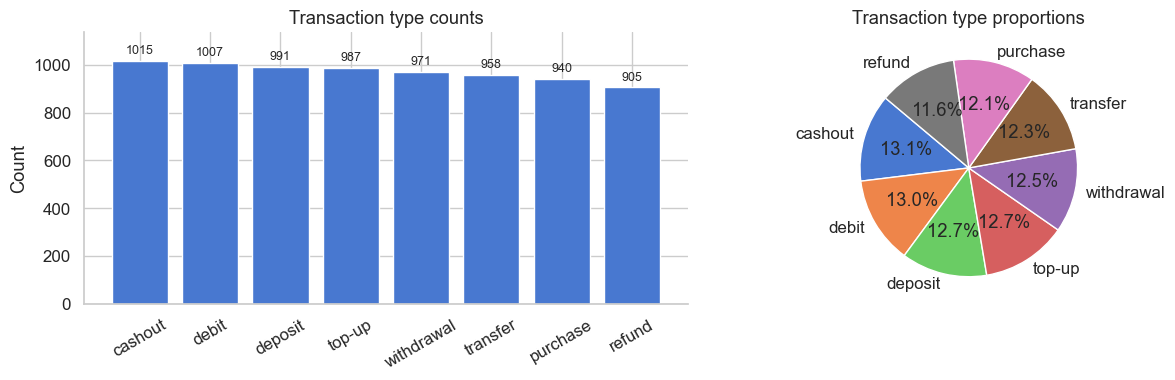

In [6]:
txn_counts = df['txn_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — absolute counts
bars = axes[0].bar(txn_counts.index, txn_counts.values, color=COLORS[0], edgecolor='white')
axes[0].bar_label(bars, padding=3, fontsize=9)
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction type counts')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, txn_counts.max() * 1.12)

# Pie chart — proportions
axes[1].pie(txn_counts.values, labels=txn_counts.index,
            autopct='%1.1f%%', colors=COLORS, startangle=140)
axes[1].set_title('Transaction type proportions')

sns.despine(ax=axes[0])
plt.tight_layout()
plt.show()

## 7. Amount Distribution

Amount is the most important numeric feature in fraud detection.
look at:
- **Histogram** — overall shape and range
- **Boxplot by transaction type** — whether certain types tend toward higher amounts
- **High-value transactions** — amounts above 4,000 that may signal fraud

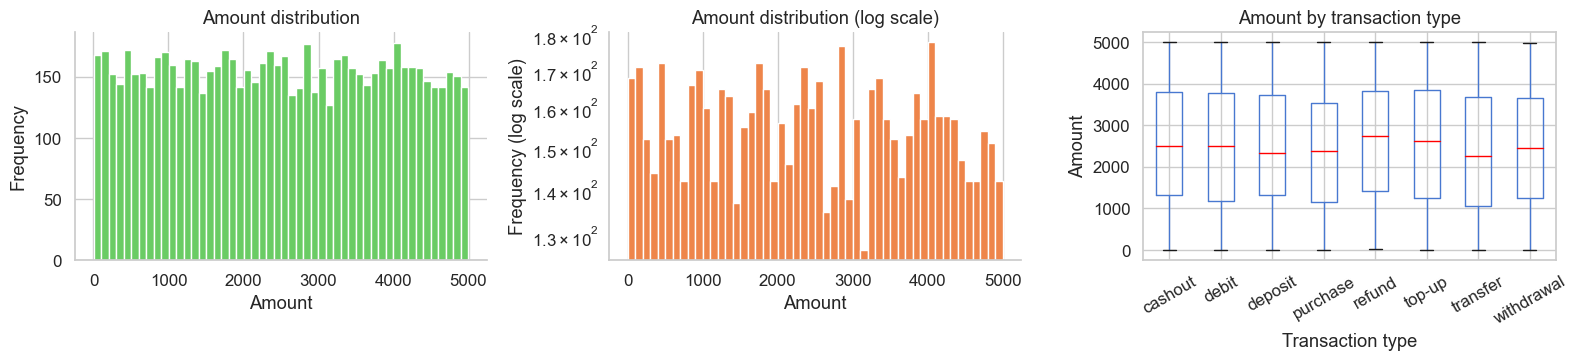

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram of all amounts
axes[0].hist(df['amount'], bins=50, color=COLORS[2], edgecolor='white')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount distribution')

# Log-scale histogram to reveal low-amount tail
axes[1].hist(df['amount'], bins=50, color=COLORS[1], edgecolor='white', log=True)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Amount distribution (log scale)')

# Boxplot per transaction type
df.boxplot(column='amount', by='txn_type', ax=axes[2],
           boxprops=dict(color=COLORS[0]),
           medianprops=dict(color='red'),
           whiskerprops=dict(color=COLORS[0]))
axes[2].set_title('Amount by transaction type')
axes[2].set_xlabel('Transaction type')
axes[2].set_ylabel('Amount')
plt.suptitle('')
axes[2].tick_params(axis='x', rotation=30)

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

In [8]:
# High-value transactions (amount >= 4000)
# These are candidates for fraud flags in label simulation
high_val = df[df['amount'] >= 4000]

print('High-value transactions (amount >= 4000)')
print('  Count      :', len(high_val))
print('  Percentage : {:.1f}%'.format(len(high_val) / len(df) * 100))
print()
print('By transaction type:')
print(high_val['txn_type'].value_counts().to_string())

High-value transactions (amount >= 4000)
  Count      : 1523
  Percentage : 19.6%

By transaction type:
cashout       215
top-up        212
debit         206
deposit       192
refund        187
transfer      182
withdrawal    169
purchase      160


## 8. Temporal Analysis

Fraud often clusters at specific times. I analyse:
- **Daily volume** — is there a pattern over the 59-day window?
- **Hourly distribution** — do transactions spike at unusual hours?
- **Day of week** — weekday vs weekend activity

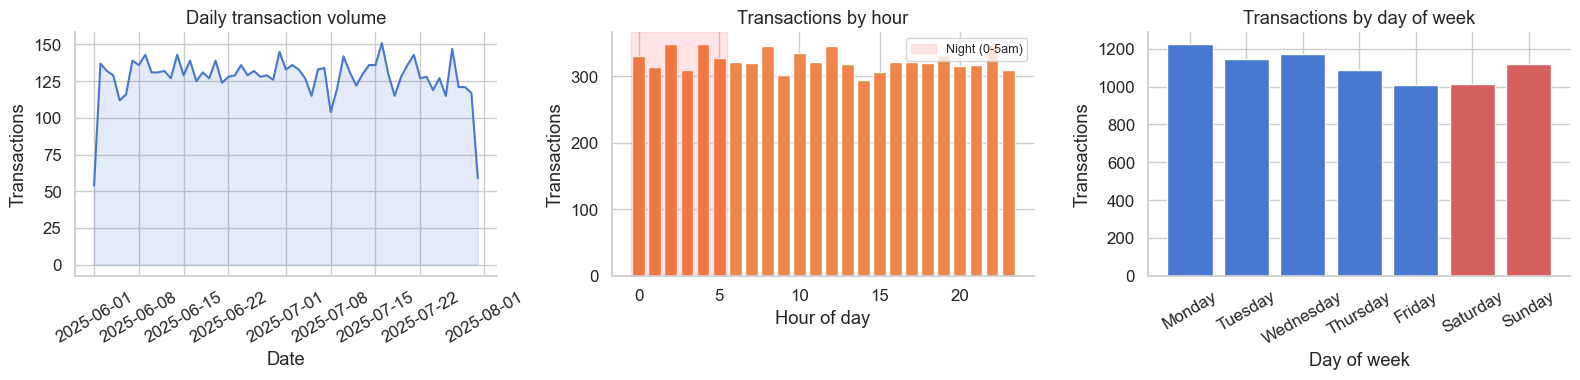

In [9]:
# Extract time features from timestamp
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['date'] = df['timestamp'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Daily transaction volume over time
daily = df.groupby('date').size()
axes[0].plot(list(daily.index), daily.values, color=COLORS[0], linewidth=1.5)
axes[0].fill_between(list(daily.index), daily.values, alpha=0.15, color=COLORS[0])
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Transactions')
axes[0].set_title('Daily transaction volume')
axes[0].tick_params(axis='x', rotation=30)

# Hourly distribution
hourly = df.groupby('hour').size()
axes[1].bar(hourly.index, hourly.values, color=COLORS[1], edgecolor='white')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Transactions')
axes[1].set_title('Transactions by hour')
axes[1].axvspan(-0.5, 5.5, alpha=0.1, color='red', label='Night (0-5am)')
axes[1].legend(fontsize=9)

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(day_order)
bar_colors = [COLORS[3] if d in ['Saturday','Sunday'] else COLORS[0] for d in day_order]
axes[2].bar(dow.index, dow.values, color=bar_colors, edgecolor='white')
axes[2].set_xlabel('Day of week')
axes[2].set_ylabel('Transactions')
axes[2].set_title('Transactions by day of week')
axes[2].tick_params(axis='x', rotation=30)

sns.despine()
plt.tight_layout()
plt.show()

In [10]:
# Night transactions (00:00 - 05:59) are a key fraud signal
night_txns = df[df['hour'].between(0, 5)]

print('Night transactions (00:00 - 05:59)')
print('  Count      :', len(night_txns))
print('  Percentage : {:.1f}%'.format(len(night_txns) / len(df) * 100))
print()
print('Night transactions by type:')
print(night_txns['txn_type'].value_counts().to_string())
print()
print('Night transaction amount stats:')
print(night_txns['amount'].describe().to_string())

Night transactions (00:00 - 05:59)
  Count      : 1978
  Percentage : 25.4%

Night transactions by type:
cashout       267
deposit       264
refund        254
transfer      252
withdrawal    246
debit         237
top-up        236
purchase      222

Night transaction amount stats:
count   1978.00
mean    2493.22
std     1424.89
min        4.85
25%     1287.69
50%     2513.72
75%     3751.30
max     4996.20


## 9. User Behaviour Analysis

With 86 users. Understanding per-user behaviour is critical because fraud
is about deviation from a user's own normal pattern, not just global thresholds.

looked at:
- Transaction count per user
- Amount per user (mean and max)
- Users with unusually high activity

In [11]:
# Per-user transaction statistics
user_stats = df.groupby('user_id').agg(
    txn_count   = ('amount', 'count'),
    mean_amount = ('amount', 'mean'),
    max_amount  = ('amount', 'max'),
    total_spent = ('amount', 'sum'),
    unique_locations = ('location', 'nunique'),
    unique_devices   = ('device', 'nunique'),
).reset_index()

print('User statistics summary:')
print(user_stats.describe().to_string())

User statistics summary:
       txn_count  mean_amount  max_amount  total_spent  unique_locations  unique_devices
count      86.00        86.00       86.00        86.00             86.00           86.00
mean       90.40      2459.73     4911.61    224106.63              7.00            5.98
std        49.99       157.32      107.08    126805.59              0.00            0.15
min        29.00      1937.03     4449.64     61265.05              7.00            5.00
25%        44.00      2378.07     4875.70    109751.38              7.00            6.00
50%        80.00      2465.82     4957.04    198423.32              7.00            6.00
75%       120.75      2567.38     4982.16    307476.96              7.00            6.00
max       238.00      2821.43     4998.25    580442.64              7.00            6.00


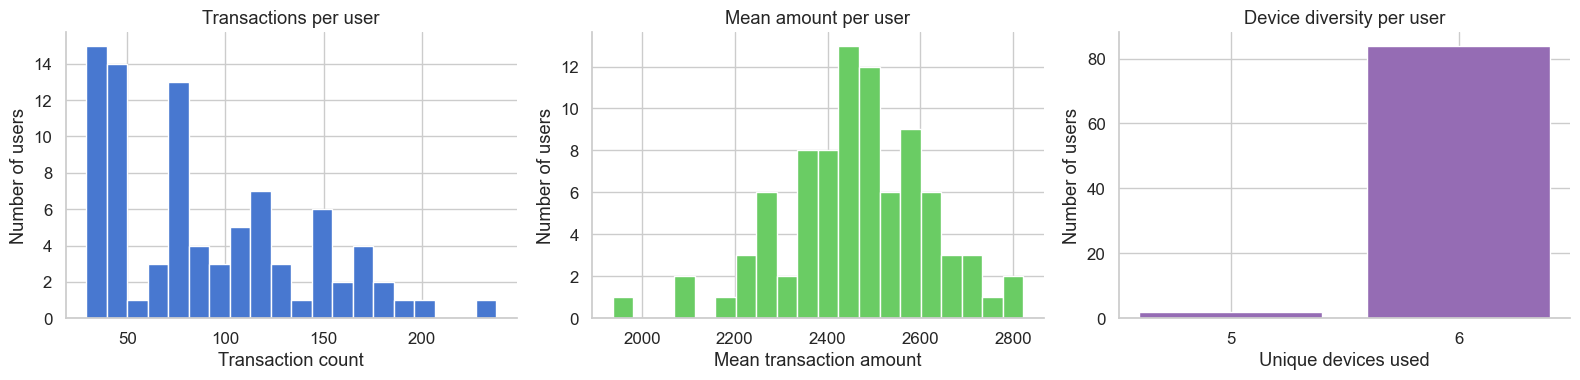

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Transaction count per user
axes[0].hist(user_stats['txn_count'], bins=20, color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Transaction count')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Transactions per user')

# Mean amount per user
axes[1].hist(user_stats['mean_amount'], bins=20, color=COLORS[2], edgecolor='white')
axes[1].set_xlabel('Mean transaction amount')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Mean amount per user')

# Unique devices per user
device_counts = user_stats['unique_devices'].value_counts().sort_index()
axes[2].bar(device_counts.index.astype(str), device_counts.values,
            color=COLORS[4], edgecolor='white')
axes[2].set_xlabel('Unique devices used')
axes[2].set_ylabel('Number of users')
axes[2].set_title('Device diversity per user')

sns.despine()
plt.tight_layout()
plt.show()

In [13]:
# Top 10 most active users
# High transaction volume is a velocity signal used in fraud detection
top_users = user_stats.nlargest(10, 'txn_count')[['user_id','txn_count','mean_amount','max_amount','unique_devices','unique_locations']]
print('Top 10 most active users:')
print(top_users.to_string(index=False))

Top 10 most active users:
 user_id  txn_count  mean_amount  max_amount  unique_devices  unique_locations
user1020        238      2438.83     4994.50               6                 7
user1081        198      2427.70     4981.17               6                 7
user1087        190      2638.15     4874.90               6                 7
user1027        180      2503.72     4967.07               6                 7
user1048        180      2567.69     4773.06               6                 7
user1029        170      2568.10     4982.26               6                 7
user1064        167      2450.87     4997.33               6                 7
user1028        166      2574.72     4985.16               6                 7
user1014        165      2511.76     4993.34               6                 7
user1058        164      2462.36     4992.62               6                 7


## 10. Location Analysis

6 cities appear in the data. Missing location is itself a signal —
legitimate transactions usually have a known location.

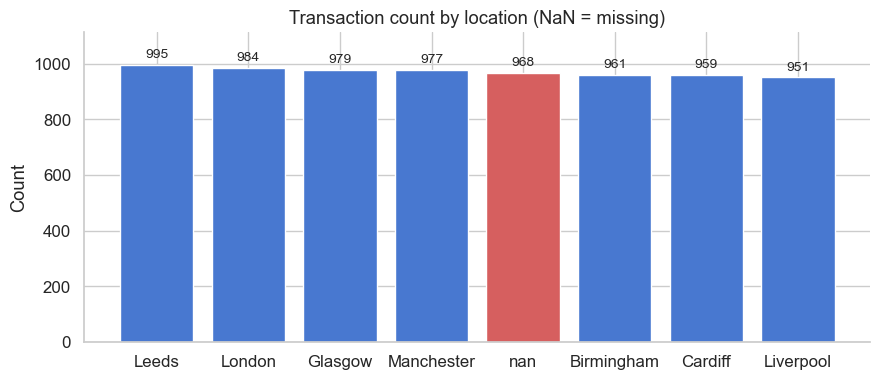

Leeds         995
London        984
Glasgow       979
Manchester    977
NaN           968
Birmingham    961
Cardiff       959
Liverpool     951


In [14]:
# Value counts including NaN
loc_counts = df['location'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [COLORS[3] if str(l) == 'nan' else COLORS[0] for l in loc_counts.index]
bars = ax.bar(loc_counts.index.astype(str), loc_counts.values,
              color=bar_colors, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Transaction count by location (NaN = missing)')
ax.set_ylim(0, loc_counts.max() * 1.12)
sns.despine()
plt.tight_layout()
plt.show()

print(loc_counts.to_string())

In [15]:
# Average transaction amount per location
# Location-based amount differences can indicate anomalies
loc_amount = df.groupby('location')['amount'].agg(['mean','median','max','count'])
loc_amount.columns = ['mean_amount','median_amount','max_amount','txn_count']
loc_amount = loc_amount.sort_values('mean_amount', ascending=False)
print('Amount statistics by location:')
print(loc_amount.to_string())

Amount statistics by location:
            mean_amount  median_amount  max_amount  txn_count
location                                                     
Glasgow         2538.56        2556.08     4996.20        979
Cardiff         2483.43        2397.49     4997.33        959
Manchester      2478.54        2442.00     4993.36        977
Liverpool       2470.27        2449.99     4996.45        951
Leeds           2458.83        2444.16     4998.25        995
Birmingham      2453.30        2449.94     4997.29        961
London          2445.45        2461.11     4985.41        984


## 11. Device Analysis

6 device types are present. A user suddenly switching devices is a red flag.
Missing device is also suspicious — legitimate apps almost always report device info.

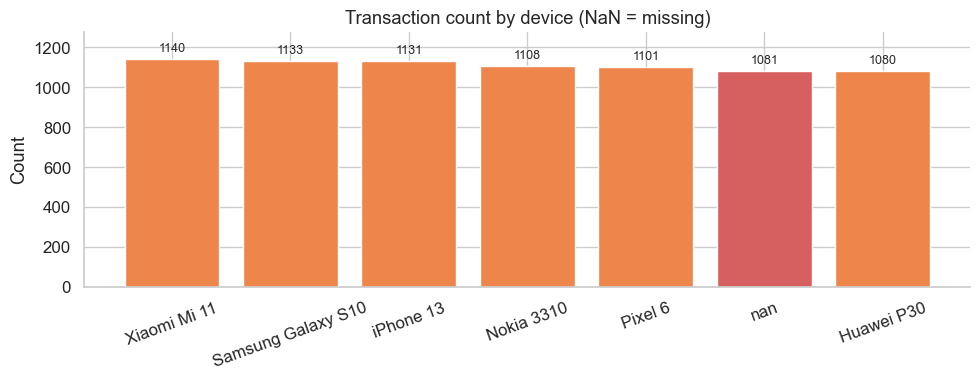

In [16]:
# Device distribution including missing
dev_counts = df['device'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [COLORS[3] if str(d) == 'nan' else COLORS[1] for d in dev_counts.index]
bars = ax.bar(dev_counts.index.astype(str), dev_counts.values,
              color=bar_colors, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Transaction count by device (NaN = missing)')
ax.set_ylim(0, dev_counts.max() * 1.12)
ax.tick_params(axis='x', rotation=20)
sns.despine()
plt.tight_layout()
plt.show()

## 12. Currency Distribution

Three currencies appear: EUR, GBP, USD.
Two formats (`pipe_colon`, `space_separated`) carry no currency symbol — those rows are NaN.
Currency inconsistency per user could be a fraud signal.

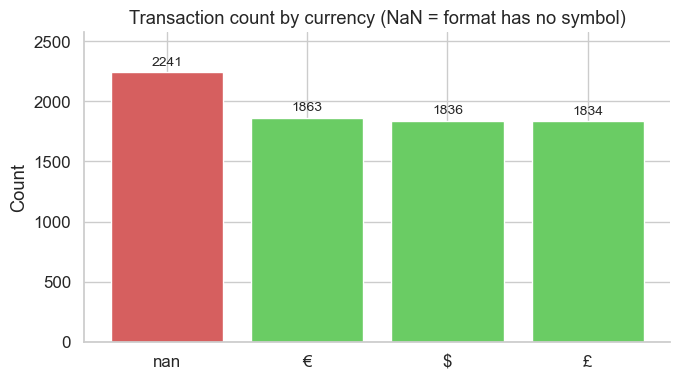

NaN    2241
€      1863
$      1836
£      1834


In [17]:
curr_counts = df['currency'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [COLORS[3] if str(c) == 'nan' else COLORS[2] for c in curr_counts.index]
bars = ax.bar(curr_counts.index.astype(str), curr_counts.values,
              color=bar_colors, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Transaction count by currency (NaN = format has no symbol)')
ax.set_ylim(0, curr_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(curr_counts.to_string())

## 13. Correlation Analysis

Correlation between numeric features.
Since we only have `amount` and time-derived columns at this stage,
this is a baseline that will expand significantly after feature engineering.

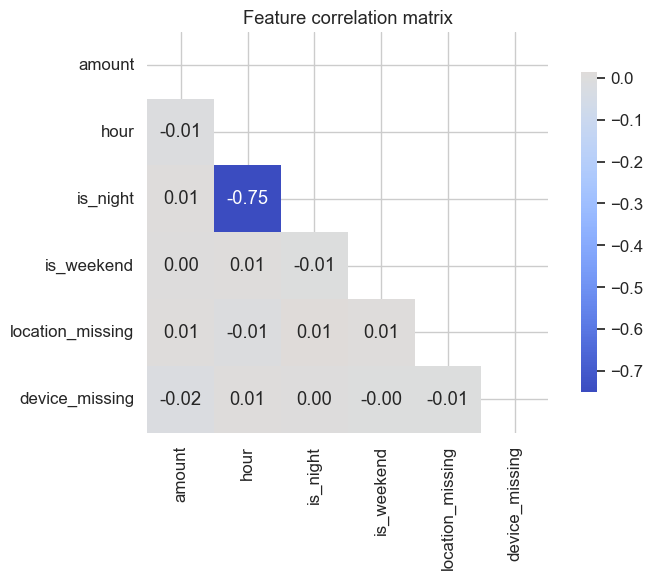

In [18]:
# Build a small numeric frame from available columns
corr_df = df[['amount', 'hour']].copy()
corr_df['is_night'] = df['hour'].between(0, 5).astype(int)
corr_df['is_weekend'] = df['timestamp'].dt.dayofweek.ge(5).astype(int)
corr_df['location_missing'] = df['location'].isna().astype(int)
corr_df['device_missing'] = df['device'].isna().astype(int)

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicate)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## Key Findings from Exploratory Data Analysis (EDA)

The dataset contains **7,774 transactions** recorded between **2025-06-01 and 2025-07-31**, involving **86 unique users** and **8 transaction types**. Transaction amounts range from **1.62 to 4,998.25**, with an average transaction value of **2,479.18**. A notable **25.4% (1,978)** of transactions occurred during nighttime hours (**00:00–05:59**), while **19.6% (1,523)** were classified as high-value transactions (amounts ≥ 4,000). Additionally, **37.9% (2,944)** of transactions belonged to potentially risky transaction categories, including cashouts, withdrawals, and transfers.

Data quality assessment revealed missing values in several important fields: **12.5% (968)** of transactions lacked location information, **13.9% (1,081)** were missing device details, and **28.8% (2,241)** had no recorded currency.

### Fraud Simulation Signals Identified

The exploratory analysis highlighted several patterns commonly associated with fraudulent activity, including:

- Nighttime transactions (**00:00–05:59**)
- High-value transactions (**amount ≥ 4,000**)
- Risky transaction types (**cashout, withdrawal, transfer**)
- Missing location or device information
- High transaction velocity (multiple transactions within a short time frame)
- Frequent device switching between consecutive transactions